# Video Game Sales Analysis

**The goal of this project is to analyze video game sales data to identify patterns that determine a game's success. The insights will help plan effective advertising campaigns for 2017 by targeting the right platforms, genres, and regions. The analysis involves exploring the dataset, handling missing values, and conducting Exploratory Data Analysis (EDA) to understand trends in platforms, genres, and ratings. We will also perform hypothesis testing to compare user ratings between different platforms and genres. Finally, we will provide insights and recommendations for the 2017 marketing campaign based on the identified trends and high-performing categories.**


## Data Description

The dataset contains information about video game sales globally and includes various features:

- **Name**: The title of the game.
- **Platform**: The gaming platform (PS4, Xbox One).
- **Year_of_Release**: The year the game was released.
- **Genre**: The type of game (Action, Sports).
- **NA_sales**: Sales in North America (in millions of USD).
- **EU_sales**: Sales in Europe (in millions of USD).
- **JP_sales**: Sales in Japan (in millions of USD).
- **Other_sales**: Sales in other countries (in millions of USD).
- **Critic_Score**: The score given by critics (on a scale of 1 to 100).
- **User_Score**: The score given by users (on a scale of 1 to 10).
- **Rating**: ESRB rating (E, T, M).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind

In [2]:
games = pd.read_csv('/datasets/games.csv', sep=',')
display(games)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


***There are noticeable missing values in columns like Critic_Score, User_Score, and Rating, indicating that some data is incomplete, particularly for older games. The dataset also shows sales data in different regions (NA_sales, EU_sales, JP_sales, Other_sales), highlighting the variability in regional popularity for different games and platforms.***

In [3]:
missing_values = games.isnull().sum() / len(games) * 100
games.columns = games.columns.str.lower()
games = games.dropna(subset=['name', 'platform', 'year_of_release', 'genre'])

games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')
games['rating'] = games['rating'].fillna('unknown')

games['total_sales'] = games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
display(games)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,unknown,0.01


 ***Missing values in year_of_release, critic_score, user_score, and rating were filled using appropriate strategies: year_of_release was filled with the most frequent year, critic_score and user_score were filled with their respective median values, and rating was filled with the most common value. A new column, total_sales, was added to represent the sum of sales across different regions (na_sales, eu_sales, jp_sales, other_sales).***

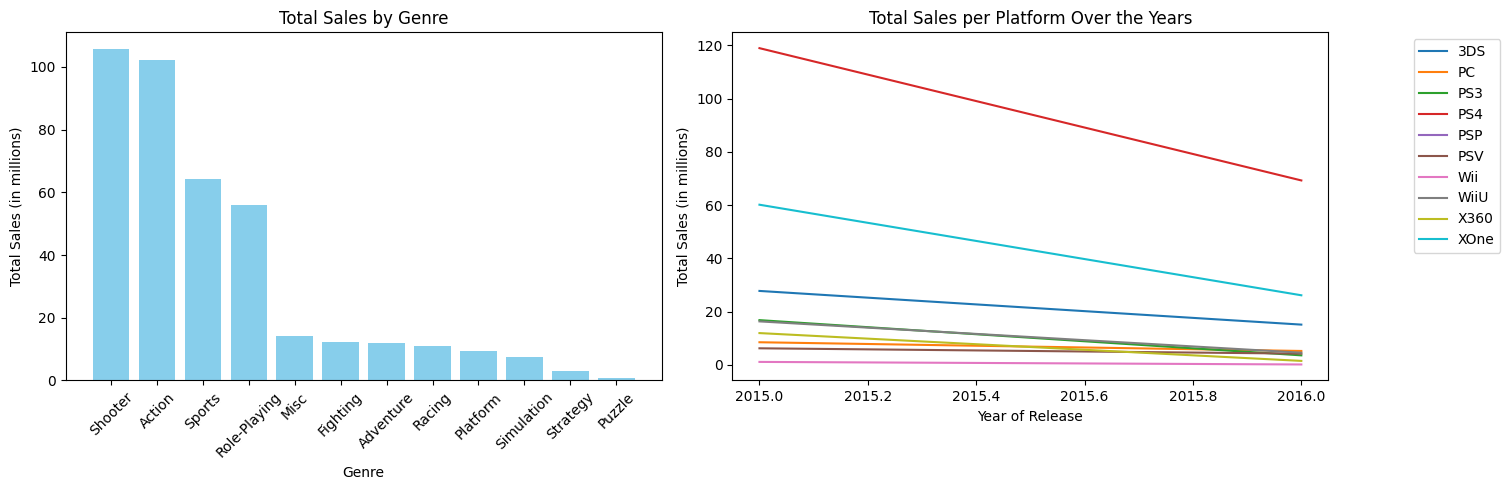

In [4]:
relevant_games = games[games['year_of_release'] >= 2015]
genre_sales = relevant_games.groupby('genre').agg(
    total_sales=('total_sales', 'sum'),
    num_games=('name', 'count')
).sort_values(by='total_sales', ascending=False)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.bar(genre_sales.index, genre_sales['total_sales'], color='skyblue')
plt.xlabel('Genre')
plt.ylabel('Total Sales (in millions)')
plt.title('Total Sales by Genre')
plt.xticks(rotation=45)

platform_sales = relevant_games.groupby(['platform', 'year_of_release']).agg(total_sales=('total_sales', 'sum')).reset_index()
plt.subplot(1, 2, 2)
for platform in platform_sales['platform'].unique():
    platform_data = platform_sales[platform_sales['platform'] == platform]
    plt.plot(platform_data['year_of_release'], platform_data['total_sales'], label=platform)
plt.xlabel('Year of Release')
plt.ylabel('Total Sales (in millions)')
plt.title('Total Sales per Platform Over the Years')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.show()

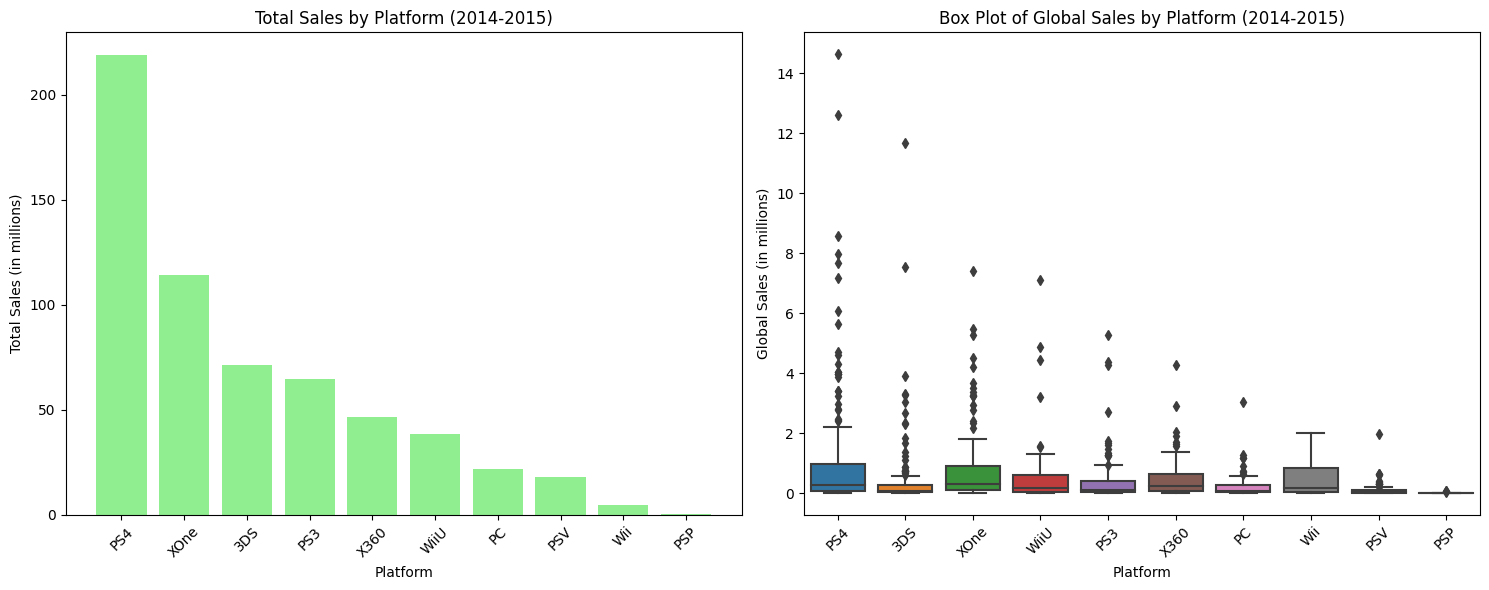

In [5]:
filtered_games = games[(games['year_of_release'] >= 2014) & (games['year_of_release'] <= 2015)]
platform_sales_summary = filtered_games.groupby('platform').agg(total_sales=('total_sales', 'sum')).sort_values(by='total_sales', ascending=False)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.bar(platform_sales_summary.index, platform_sales_summary['total_sales'], color='lightgreen')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in millions)')
plt.title('Total Sales by Platform (2014-2015)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(x='platform', y='total_sales', data=filtered_games)
plt.xlabel('Platform')
plt.ylabel('Global Sales (in millions)')
plt.title('Box Plot of Global Sales by Platform (2014-2015)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

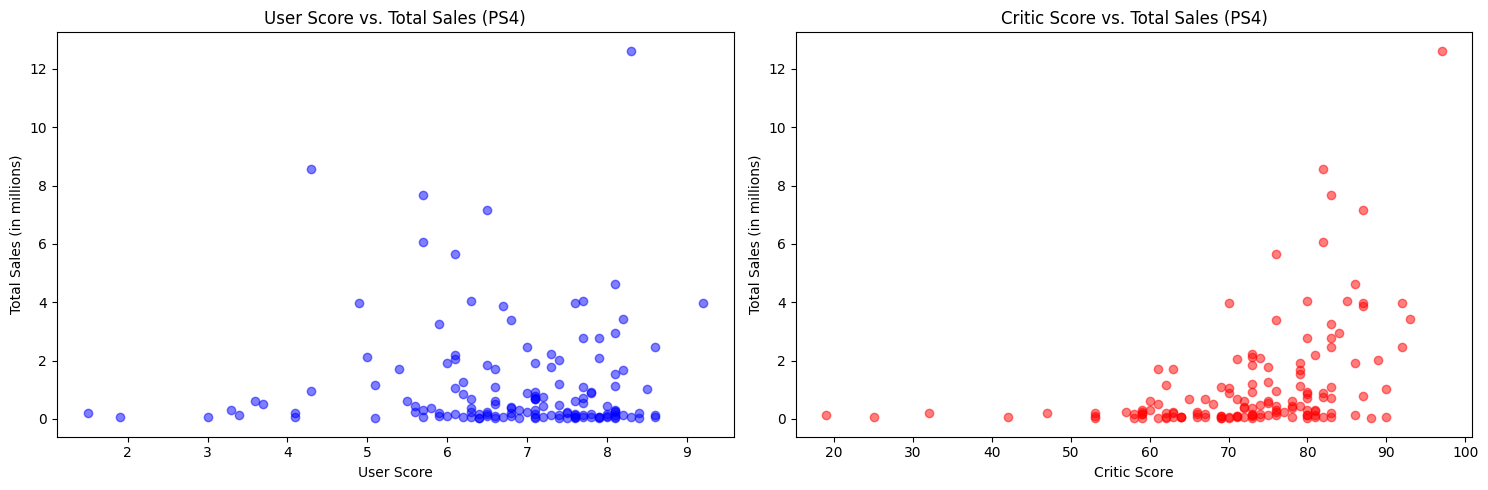

Correlation between User Score and Total Sales (PS4): 0.005328260777115949
Correlation between Critic Score and Total Sales (PS4): 0.4290034702738607


In [6]:
ps4_games = filtered_games[filtered_games['platform'] == 'PS4']
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(ps4_games['user_score'], ps4_games['total_sales'], alpha=0.5, color='blue')
plt.xlabel('User Score')
plt.ylabel('Total Sales (in millions)')
plt.title('User Score vs. Total Sales (PS4)')

plt.subplot(1, 2, 2)
plt.scatter(ps4_games['critic_score'], ps4_games['total_sales'], alpha=0.5, color='red')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (in millions)')
plt.title('Critic Score vs. Total Sales (PS4)')

plt.tight_layout()
plt.show()

correlation_user_sales = ps4_games['user_score'].corr(ps4_games['total_sales'])
correlation_critic_sales = ps4_games['critic_score'].corr(ps4_games['total_sales'])
print("Correlation between User Score and Total Sales (PS4):", correlation_user_sales)
print("Correlation between Critic Score and Total Sales (PS4):", correlation_critic_sales)

***The displayed dataset provides a summary of total sales by genre from 2000 onwards. Action, Sports, and Shooter are the leading genres in terms of total sales, with Action at 1,553.81 million units sold across 3,141 games, followed by Sports at 1,152.52 million units, and Shooter at 923.79 million units. On the other hand, genres like Puzzle and Strategy have relatively lower total sales of 140.88 million and 116.73 million, respectively, indicating they cater to a more niche audience.***

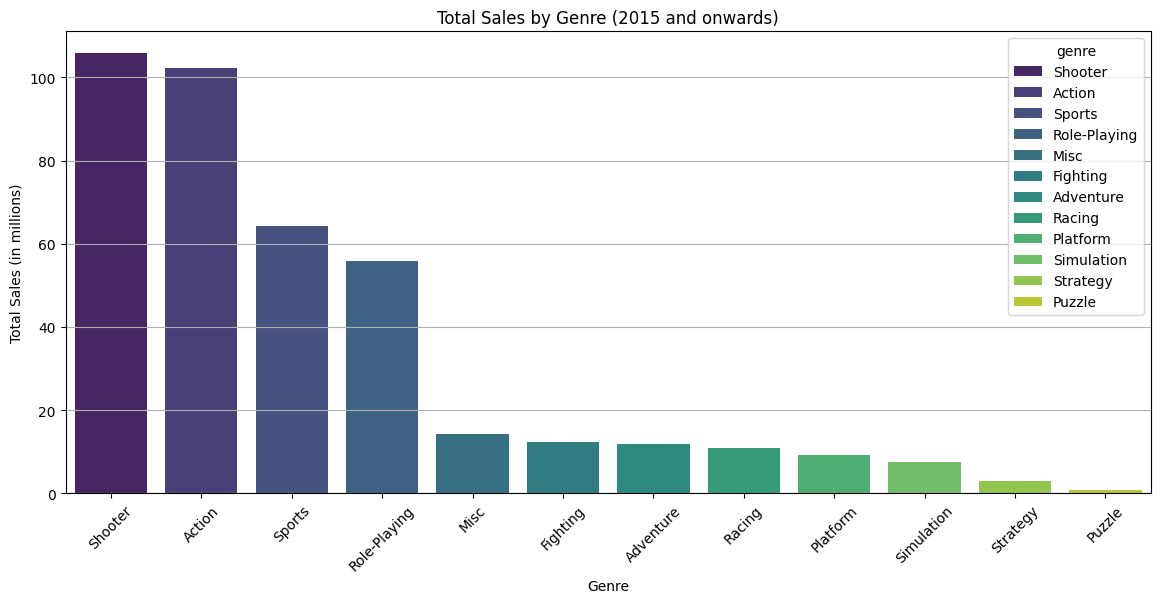

In [7]:
plt.figure(figsize=(14, 6))
sns.barplot(x='genre', y='total_sales', data=genre_sales.reset_index(), palette='viridis', hue='genre', dodge=False)
plt.xlabel('Genre')
plt.ylabel('Total Sales (in millions)')
plt.title('Total Sales by Genre (2015 and onwards)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

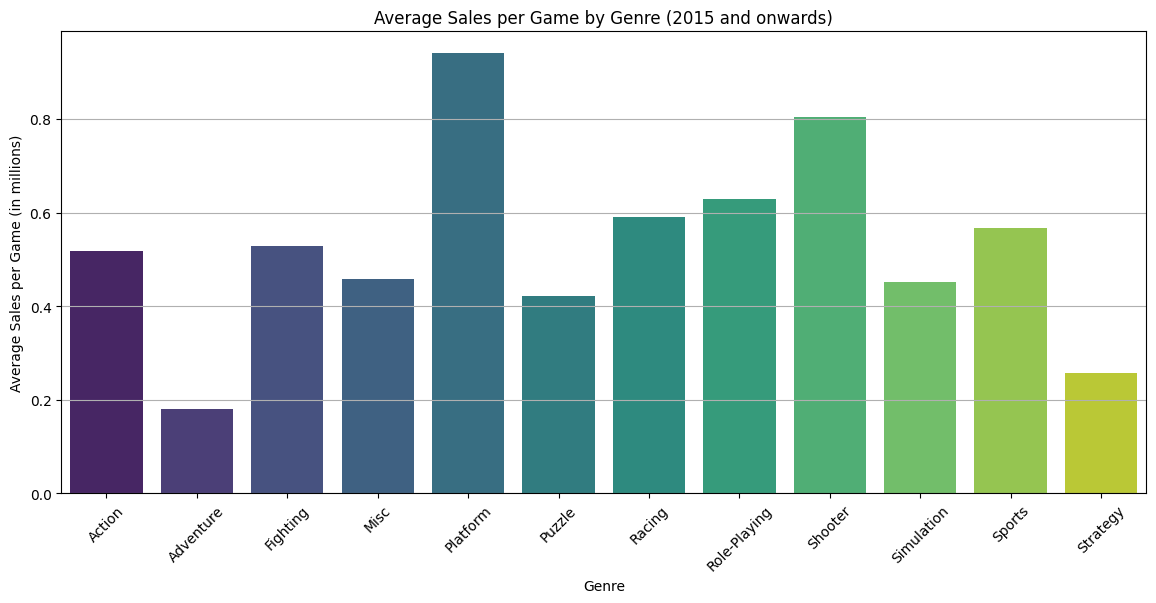

In [8]:
games['total_sales'] = games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

genre_sales = games.groupby('genre')['total_sales'].sum().reset_index()
genre_counts = games['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

genre_avg_sales_df = pd.merge(genre_sales, genre_counts, on='genre')
genre_avg_sales_df['avg_sales'] = genre_avg_sales_df['total_sales'] / genre_avg_sales_df['count']

plt.figure(figsize=(14, 6))
sns.barplot(x='genre', y='avg_sales', data=genre_avg_sales_df, palette='viridis', dodge=False)
plt.xlabel('Genre')
plt.ylabel('Average Sales per Game (in millions)')
plt.title('Average Sales per Game by Genre (2015 and onwards)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

***The bar chart shows the total sales by genre from 2000 onwards. The Action genre has the highest sales, surpassing 1,500 million units, followed by Sports and Shooter, each with over 1,000 million units. Genres such as Role-Playing and Miscellaneous also have significant sales, although lower compared to the top three. Meanwhile, Puzzle and Strategy genres have the lowest total sales, indicating their more niche appeal.***

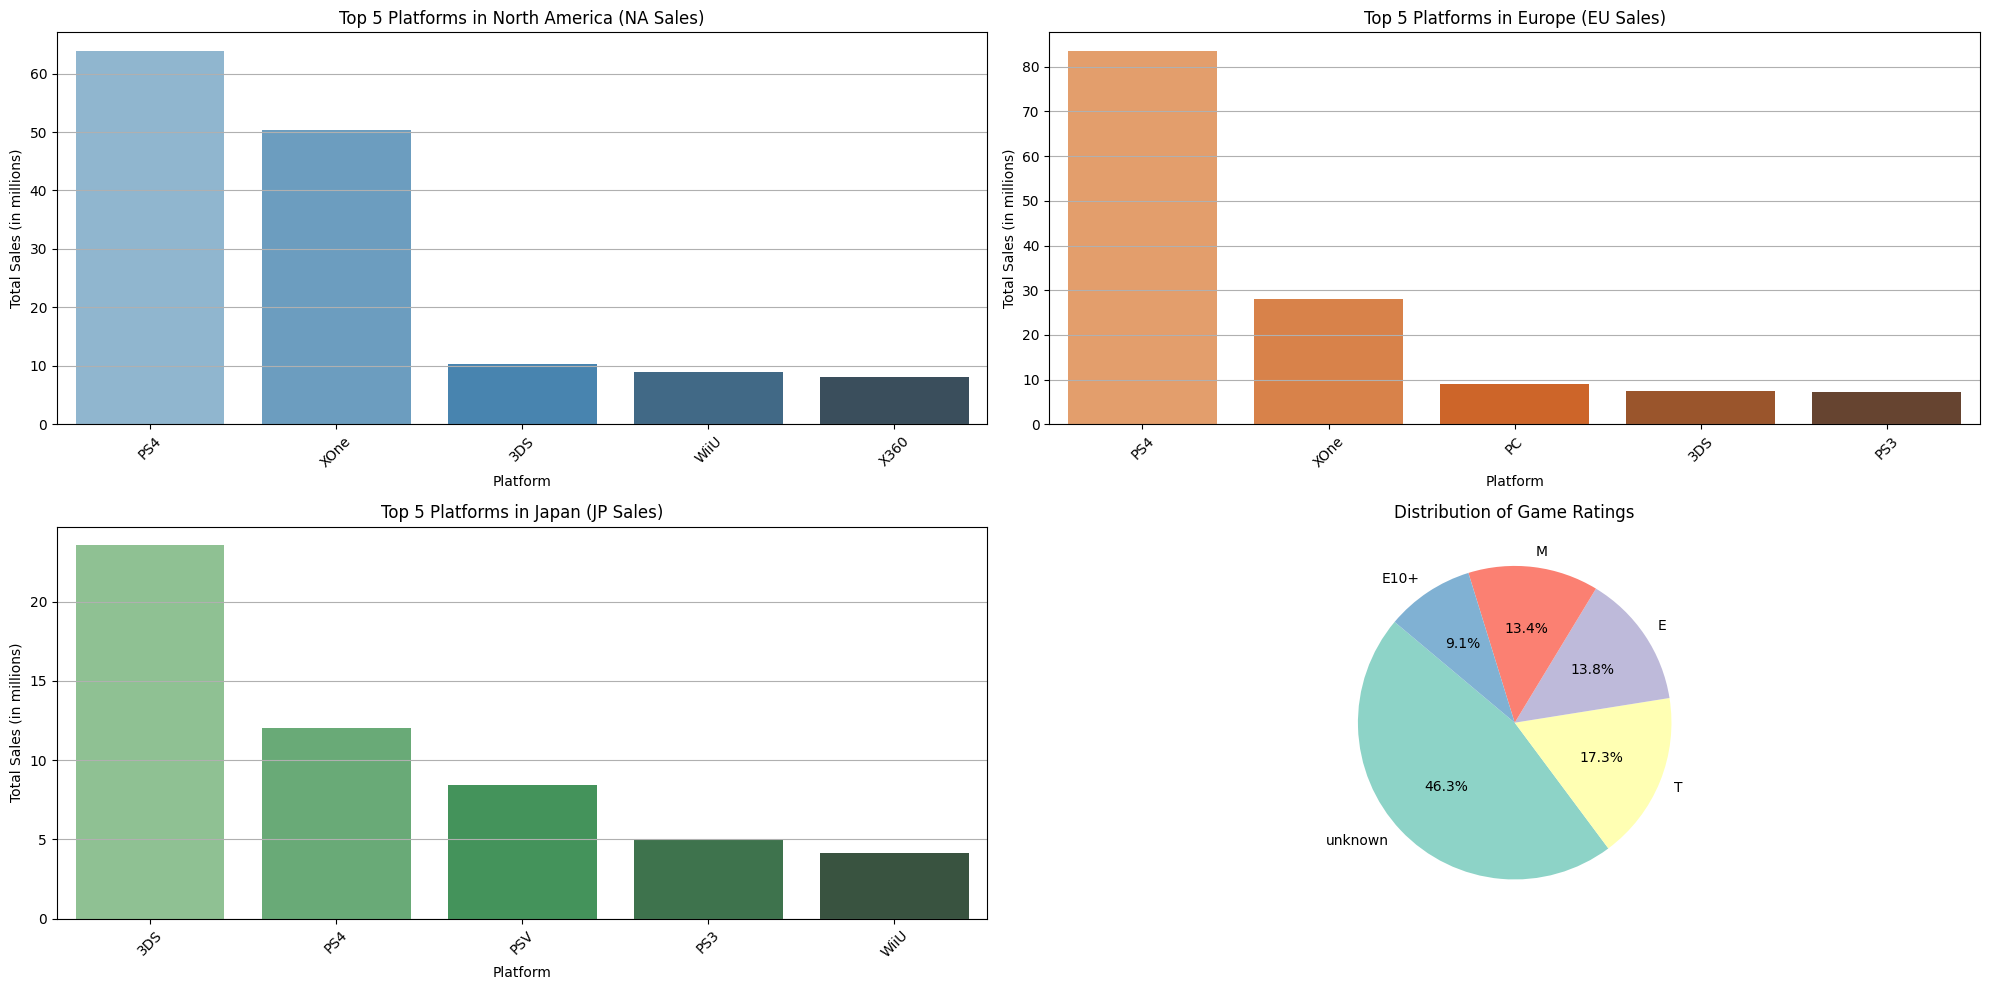

In [9]:
platform_sales_region = relevant_games.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales']].sum()
top_platforms_na = platform_sales_region['na_sales'].sort_values(ascending=False).head(5)
top_platforms_eu = platform_sales_region['eu_sales'].sort_values(ascending=False).head(5)
top_platforms_jp = platform_sales_region['jp_sales'].sort_values(ascending=False).head(5)

plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
sns.barplot(x=top_platforms_na.index, y=top_platforms_na.values, palette='Blues_d')
plt.title('Top 5 Platforms in North America (NA Sales)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in millions)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.subplot(2, 2, 2)
sns.barplot(x=top_platforms_eu.index, y=top_platforms_eu.values, palette='Oranges_d')
plt.title('Top 5 Platforms in Europe (EU Sales)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in millions)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.subplot(2, 2, 3)
sns.barplot(x=top_platforms_jp.index, y=top_platforms_jp.values, palette='Greens_d')
plt.title('Top 5 Platforms in Japan (JP Sales)')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in millions)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.subplot(2, 2, 4)
rating_counts = relevant_games['rating'].value_counts()
rating_labels = rating_counts.index
rating_sizes = rating_counts.values

plt.pie(rating_sizes, labels=rating_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
plt.title('Distribution of Game Ratings')

plt.tight_layout()
plt.show()

***These differences suggest distinct preferences in gaming platforms across regions, with Xbox leading in North America, PlayStation performing well in Europe, and Nintendo dominating in Japan, particularly with portable consoles.***

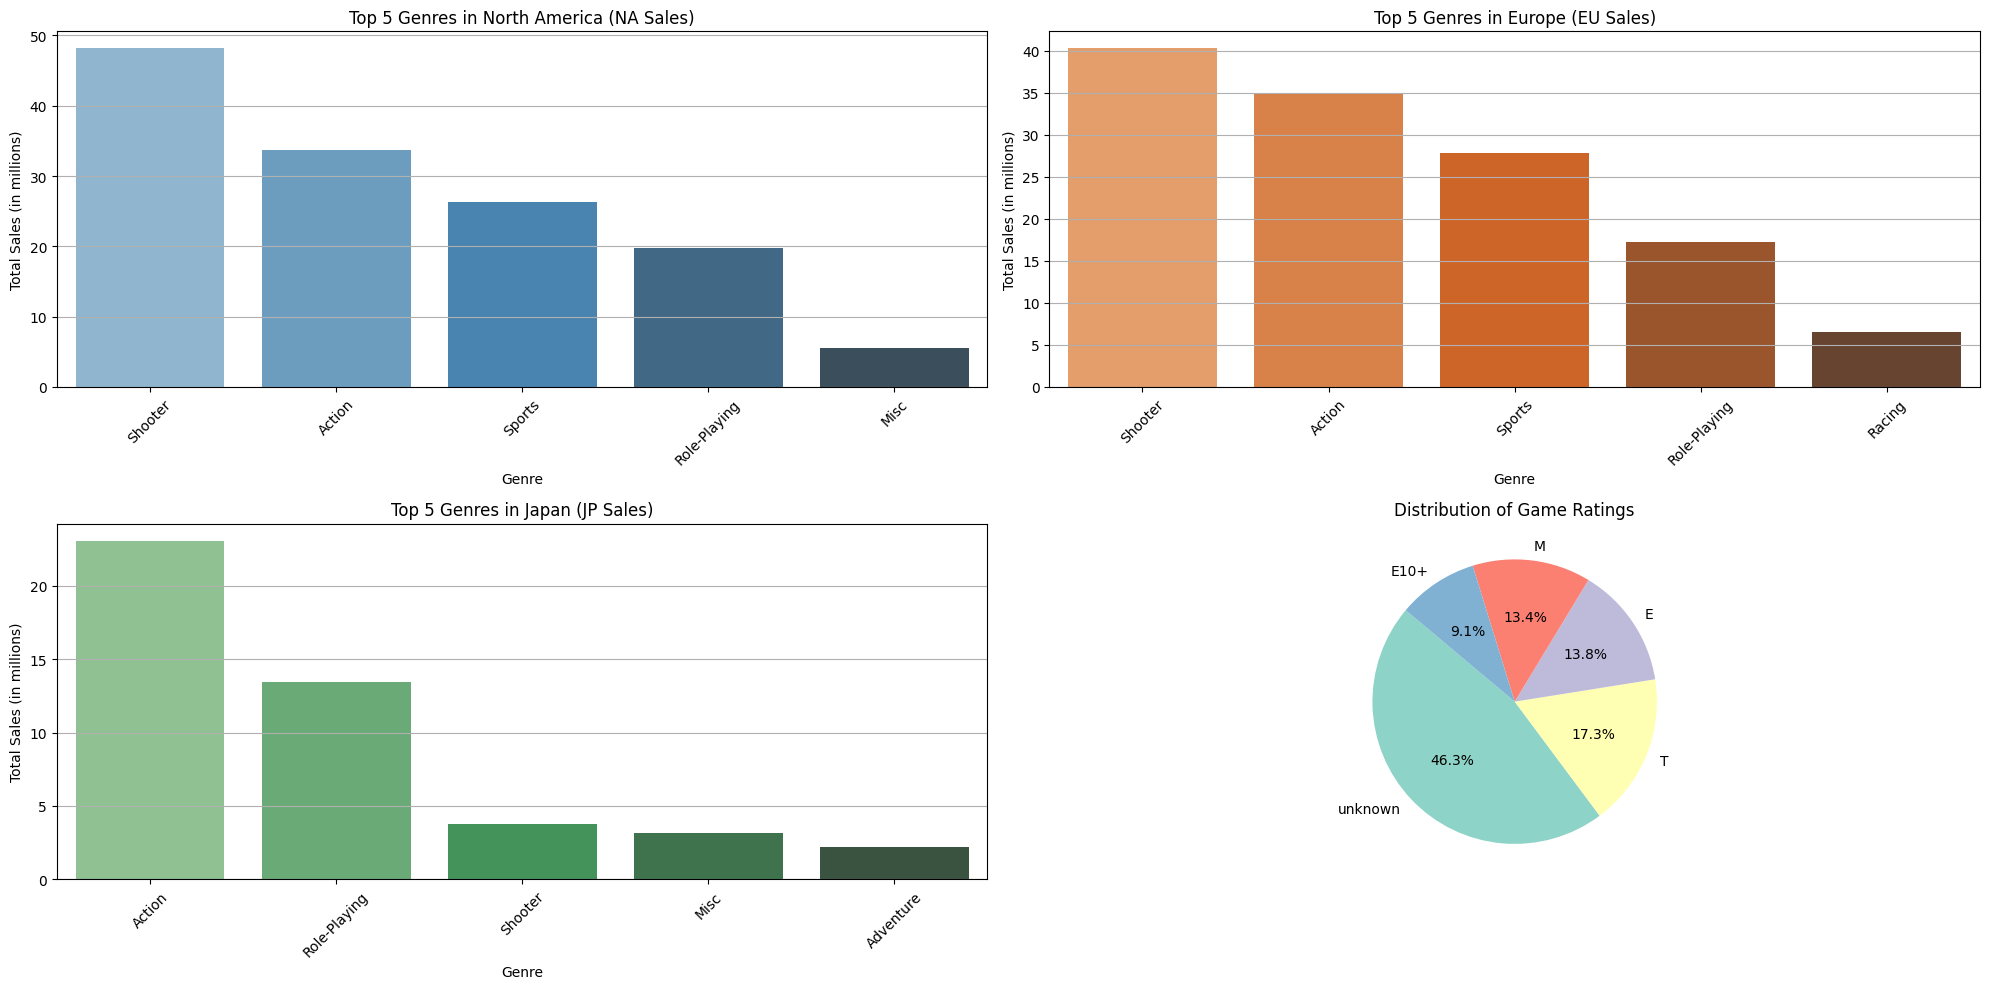

In [10]:
genre_sales_region = relevant_games.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']].sum()
top_genres_na = genre_sales_region['na_sales'].sort_values(ascending=False).head(5)
top_genres_eu = genre_sales_region['eu_sales'].sort_values(ascending=False).head(5)
top_genres_jp = genre_sales_region['jp_sales'].sort_values(ascending=False).head(5)

plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
sns.barplot(x=top_genres_na.index, y=top_genres_na.values, palette='Blues_d')
plt.title('Top 5 Genres in North America (NA Sales)')
plt.xlabel('Genre')
plt.ylabel('Total Sales (in millions)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.subplot(2, 2, 2)
sns.barplot(x=top_genres_eu.index, y=top_genres_eu.values, palette='Oranges_d')
plt.title('Top 5 Genres in Europe (EU Sales)')
plt.xlabel('Genre')
plt.ylabel('Total Sales (in millions)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.subplot(2, 2, 3)
sns.barplot(x=top_genres_jp.index, y=top_genres_jp.values, palette='Greens_d')
plt.title('Top 5 Genres in Japan (JP Sales)')
plt.xlabel('Genre')
plt.ylabel('Total Sales (in millions)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.subplot(2, 2, 4)
rating_counts = relevant_games['rating'].value_counts()
rating_labels = rating_counts.index
rating_sizes = rating_counts.values

plt.pie(rating_sizes, labels=rating_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
plt.title('Distribution of Game Ratings')

plt.tight_layout()
plt.show()

***The results suggest distinct regional preferences: Action, Sports, and Shooter dominate in North America and Europe, whereas Role-Playing is by far the most popular in Japan. This emphasizes the importance of targeting genre preferences according to regional tastes for game publishers.***

In [11]:
xone_ratings = relevant_games[relevant_games['platform'] == 'XOne']['user_score'].dropna()
pc_ratings = relevant_games[relevant_games['platform'] == 'PC']['user_score'].dropna()

t_stat_xone_pc, p_value_xone_pc = ttest_ind(xone_ratings, pc_ratings, equal_var=False)
print("T-test for Xbox One vs. PC:")
print(f"T-statistic: {t_stat_xone_pc:.3f}, P-value: {p_value_xone_pc:.9f}")

T-test for Xbox One vs. PC:
T-statistic: 1.052, P-value: 0.294630886


## Hypothesis Testing for Platforms: Xbox One vs. PC

### Formulate the Hypotheses

**Null Hypothesis (H₀)**: The average user ratings of **Xbox One** and **PC** platforms are equal.

**Alternative Hypothesis (Hₐ)**: The average user ratings of **Xbox One** and **PC** platforms are **not equal**.


In [12]:
alpha = 0.05
if p_value_xone_pc < alpha:
    print("Reject the null hypothesis: Average user ratings of Xbox One and PC are significantly different.")
else:
    print("Fail to reject the null hypothesis: Average user ratings of Xbox One and PC are not significantly different.")

Fail to reject the null hypothesis: Average user ratings of Xbox One and PC are not significantly different.


## Hypothesis Testing for Genres: Action vs. Sports

### Formulate the Hypotheses

**Null Hypothesis (H₀)**: The average user ratings for **Action** and **Sports** genres are equal.

**Alternative Hypothesis (Hₐ)**: The average user ratings for **Action** and **Sports** genres are different.


In [13]:
action_ratings = relevant_games[relevant_games['genre'] == 'Action']['user_score'].dropna()
sports_ratings = relevant_games[relevant_games['genre'] == 'Sports']['user_score'].dropna()
t_stat_action_sports, p_value_action_sports = ttest_ind(action_ratings, sports_ratings, equal_var=False)

print("\nT-test for Action vs. Sports genres:")
print(f"T-statistic: {t_stat_action_sports:.3f}, P-value: {p_value_action_sports:.3f}")

if p_value_action_sports < alpha:
    print("Reject the null hypothesis: Average user ratings for Action and Sports genres are significantly different.")
else:
    print("Fail to reject the null hypothesis: Average user ratings for Action and Sports genres are not significantly different.")


T-test for Action vs. Sports genres:
T-statistic: 6.764, P-value: 0.000
Reject the null hypothesis: Average user ratings for Action and Sports genres are significantly different.


**In this project, I analyzed video game sales data up to 2016 to identify patterns that could help plan a successful advertising campaign for 2017. I found that Action, Sports, and Shooter genres were the most successful globally, while Role-Playing was particularly dominant in Japan. Regionally, the Xbox 360 led sales in North America, PlayStation platforms were popular in Europe, and Nintendo DS was the leader in Japan, showing clear regional preferences. E-rated games had the broadest appeal across all markets, and critic scores showed a positive correlation with sales, suggesting that expert reviews play a significant role in a game's success.**